# **Simple Regression Problems**
* Classification: output variable is categorical (or discrete)
* Regression: output variable is numerical (or continuous)
* Logistic Regression: output is between 0 and 1 (commonly used for binary classification tasks)

Example of Regression: Predicting House Prices

![alt text](https://www.pyimagesearch.com/wp-content/uploads/2019/01/keras_regression_classification_vs_reg.png)



In [ ]:
import numpy as np
from keras.models import Sequential
from keras.layers import Dense
from keras import optimizers


## (Review of) Python Basics

Numpy axis

https://www.sharpsightlabs.com/blog/numpy-axes-explained/

In [ ]:
X = np.array([[1,2],[3,4]])
np.mean(X) # default is to computer the mean of flattened array

2.5

In [ ]:
np.mean(X, axis=0) # axis=0 means row. row is collapsed

array([2., 3.])

In [ ]:
np.mean(X, axis=1) # axis=1 means column. column is collapsed

array([1.5, 3.5])

In [ ]:
# Reshape test
z = np.array([[1, 2, 3, 4],
              [5, 6, 7, 8],
              [9, 10, 11, 12]])
z.shape

(3, 4)

In [ ]:
print(z.reshape(4,3))

[[ 1  2  3]
 [ 4  5  6]
 [ 7  8  9]
 [10 11 12]]


In [ ]:
z.reshape(-1, 3)
# -1 simply means that it is an unknown dimension
# and we want numpy to figure it out.

array([[ 1,  2,  3],
       [ 4,  5,  6],
       [ 7,  8,  9],
       [10, 11, 12]])

In [ ]:
z.reshape(2, -1)

array([[ 1,  2,  3,  4,  5,  6],
       [ 7,  8,  9, 10, 11, 12]])

In [ ]:
#z.reshape(-1, -1) # Error

In [ ]:
x = np.array([1])
print(x.shape)
print(x.ndim)

(1,)
1


In [ ]:
x = np.array([1, 2, 3, 4])
print(x.shape)

(4,)


In [ ]:
x = np.array([])
print(x.shape)
print(x.ndim)

(0,)
1


In [ ]:
x = np.array([[1, 2, 3, 4]])
print(x.shape)

(1, 4)


In [ ]:
x2 = x.T
print(x2)
print(x2.shape)

[[1]
 [2]
 [3]
 [4]]
(4, 1)


In [ ]:
# Numpy array append
narr = np.array([]) # narr = np.empty([])
for _ in range(4):
    narr = np.append(narr, np.random.random()) # uniform random [0,1)
print(narr)

[0.70248928 0.76607602 0.28070331 0.97589433]


In [ ]:
print(np.random.random_sample(4))

[0.41665911 0.56532252 0.06020692 0.55893626]


In [ ]:
print(np.random.rand(4)) # uniformly distributed [0,1)

[0.8906668  0.88685488 0.29463799 0.90593483]


In [ ]:
print(np.random.random((4,1)) )  # size 4x1

[[0.13086549]
 [0.08509277]
 [0.55677022]
 [0.47159655]]


In [ ]:
print(np.random.random((4,1)).shape )

(4, 1)


### Difference between "List append" and "Numpy append"

In [ ]:
a = [0]
b = [4,5,6,7]
a.append(b)
print(a)

[0, [4, 5, 6, 7]]


In [ ]:
c = [0]
c = np.append(c,b)
print(c)

[0 4 5 6 7]


# (1) Simplest linear regression problem without hidden layers, y = 2x, simple input format

In [ ]:
X1 = np.linspace(0,1,50)
print (X1.shape)
print(X1)
Y1 = 2 * X1
print (Y1.shape)
print(Y1)

(50,)
[0.         0.02040816 0.04081633 0.06122449 0.08163265 0.10204082
 0.12244898 0.14285714 0.16326531 0.18367347 0.20408163 0.2244898
 0.24489796 0.26530612 0.28571429 0.30612245 0.32653061 0.34693878
 0.36734694 0.3877551  0.40816327 0.42857143 0.44897959 0.46938776
 0.48979592 0.51020408 0.53061224 0.55102041 0.57142857 0.59183673
 0.6122449  0.63265306 0.65306122 0.67346939 0.69387755 0.71428571
 0.73469388 0.75510204 0.7755102  0.79591837 0.81632653 0.83673469
 0.85714286 0.87755102 0.89795918 0.91836735 0.93877551 0.95918367
 0.97959184 1.        ]
(50,)
[0.         0.04081633 0.08163265 0.12244898 0.16326531 0.20408163
 0.24489796 0.28571429 0.32653061 0.36734694 0.40816327 0.44897959
 0.48979592 0.53061224 0.57142857 0.6122449  0.65306122 0.69387755
 0.73469388 0.7755102  0.81632653 0.85714286 0.89795918 0.93877551
 0.97959184 1.02040816 1.06122449 1.10204082 1.14285714 1.18367347
 1.2244898  1.26530612 1.30612245 1.34693878 1.3877551  1.42857143
 1.46938776 1.51020408 1.55

In [ ]:
m = Sequential()
m.add(Dense(1, input_shape=(1,))) # Note: no activation function is needed
#m.add(Dense(1, input_dim=1)), Note: no activation function
m.compile(loss='mse', optimizer='rmsprop')
m.fit(X1, Y1, epochs=600, verbose=0)
m.evaluate(X1, Y1)  # return loss. If the loss is not near zero, re-train!

2/2 [==============================] - 0s 8ms/step - loss: 8.7423e-07


8.74225349889457e-07

2/2 [==============================] - 0s 9ms/step


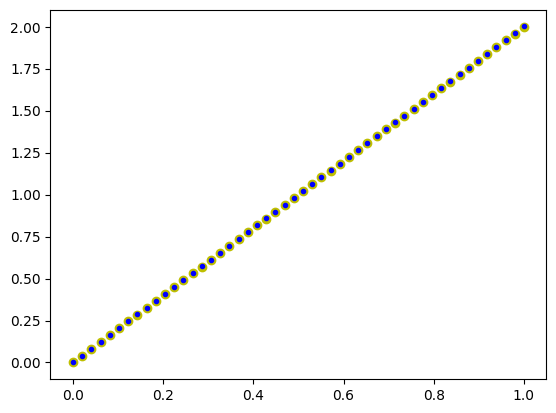

In [ ]:
from pylab import *   # You can directly call plot(...)
# What's the difference between PyLab and matplotlib?
# Matplotlib is the whole package; pylab is a module in matplotlib that gets installed alongside matplotlib
plot(X1, Y1, 'yo') # yellow circles
plot(X1, m.predict(X1), 'b.') # blue dots

# (2) Simplest linear regression problem without hidden layers, y = 2x, **typical** DL input format
Use (n, 1) shape instead of (n,), since (n, 1) is the general input format for Keras DNN models

In [ ]:
X = np.linspace(0, 1, 50).reshape(-1, 1) # -1 simply means that it is an unknown dimension and we want numpy to figure it out.
print(X[:10])
print(X.shape)
Y = 2 * X

[[0.        ]
 [0.02040816]
 [0.04081633]
 [0.06122449]
 [0.08163265]
 [0.10204082]
 [0.12244898]
 [0.14285714]
 [0.16326531]
 [0.18367347]]
(50, 1)


In [ ]:
m2 = Sequential()
m2.add(Dense(1, input_dim=1)) # this can be done with just one neuron
m2.compile(loss='mse', optimizer='rmsprop')
m2.fit(X, Y, epochs=600, verbose = 0)

In [ ]:
# Test with unseen X
X_test = np.linspace(0, 1, 30).reshape(-1, 1)
Y_test = 2*X_test
m2.evaluate(X_test, Y_test)  # If the loss is not near zero, re-train!

1/1 [==============================] - 0s 92ms/step - loss: 4.6340e-07


4.633978676338302e-07

1/1 [==============================] - 0s 52ms/step


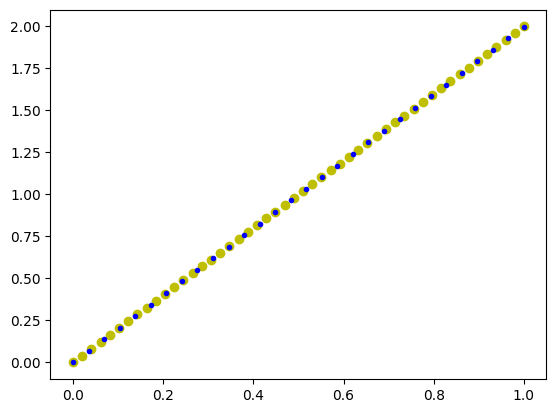

In [ ]:
plot(X, Y, 'yo') # yellow circles
plot(X_test, m2.predict(X_test), 'b.') # blue dots

In [ ]:
print (m2.get_weights())

[array([[1.9996625]], dtype=float32), array([-0.00050452], dtype=float32)]


<img src=https://www.robofest.net/DL/y_2x.JPG width=300>

# (3) A simple non-linear regression problem: y = x^2

In [ ]:
Y3 = X * X

In [ ]:
# m3 = Sequential()
# m3.add(Dense(32, input_dim=1, activation='relu'))
# m3.add(Dense(1)) # Note: no activation function defined!
# m3.compile(optimizer=optimizers.SGD(learning_rate=0.1), loss='mse')   # Proper lr is important

# #m3.compile(optimizer='adam',    loss='mse')
# #m3.compile(optimizer='rmsprop', loss='mse')
# m3.fit(X, Y3, epochs=500, batch_size=5, verbose = 0)

m3 = Sequential([
    Dense(32, input_dim=1, activation='relu'),
    Dense(1)
])
m3.compile(optimizer=optimizers.SGD(learning_rate=0.1), loss='mse')
m3.fit(X, Y3, epochs=500, batch_size=5, verbose = 0)

In [ ]:
Y3_test = X_test * X_test
m3.evaluate(X_test, Y3_test)  # return loss. If the loss is not near zero, re-train!

1/1 [==============================] - 0s 127ms/step - loss: 8.1014e-06


8.101380444713868e-06

2/2 [==============================] - 0s 5ms/step


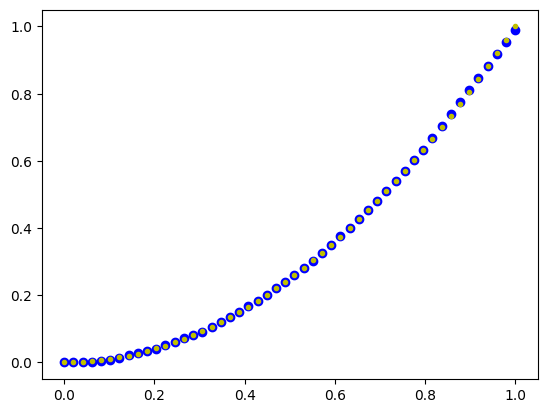

In [ ]:
plot(X, m3.predict(X), 'bo') # blue circles
plot(X, Y3, 'y.') # yellow dots

# (4) Add noise to the target function, y = x - 0.1

In [ ]:
mu, sigma = 0, 0.01 # mean and standard deviation
X_random = np.array([])
for _ in range(100):
     X_random = np.append(X_random, np.random.normal(mu, sigma))
X_random = np.array([X_random]).T # we could use reshape (-1,1)
#print(X_random)

# simpler way in the next cell

In [ ]:
#X_rand = np.random.normal (loc=0.0, scale=0.1, size=100)
#X_rand = X_rand.reshape(-1,1)
X_rand = np.random.normal (0.0, 0.1, (50,1)) # simplest way
#print(X_rand)

In [ ]:
Y4 = X - 0.1 + X_rand
#print(X, Y4)

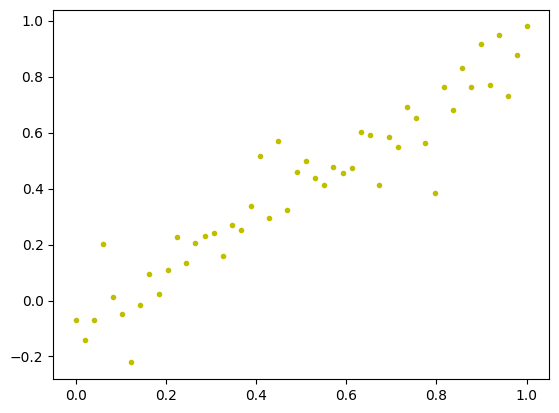

In [ ]:
plot(X, Y4, 'y.') # yellow dots

In [ ]:
m4 = Sequential()
m4.add(Dense(32, input_dim=1, activation='relu')) #
m4.add(Dense(1)) # this can be done with just one neuron
#m4.compile(optimizer='adam', loss='mse')
#m4.compile(optimizer=optimizers.SGD(lr=0.1), loss='mse') # Proper lr is important
m4.compile(optimizer='rmsprop', loss='mse')

In [ ]:
m4.fit(X, Y4, epochs=500, batch_size=5, verbose=0)
loss = m4.evaluate(X, Y4)
print(loss)

2/2 [==============================] - 0s 10ms/step - loss: 0.0096
0.009557360783219337


2/2 [==============================] - 0s 8ms/step


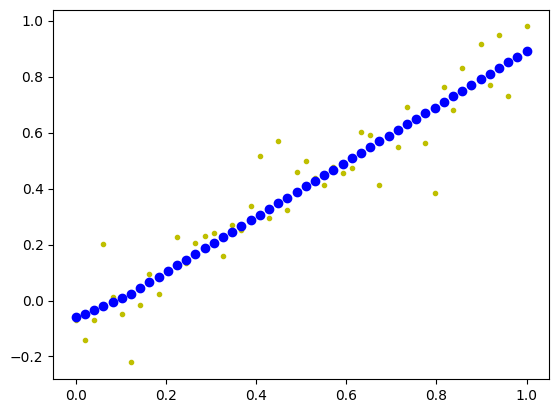

In [ ]:
plot(X, Y4, 'y.') # yellow dots
plot(X, m4.predict(X), 'bo') # blue circles

In [ ]:
# inference with input X
m4.predict(X[:3], verbose=0)

array([[-0.06038534],
       [-0.04725972],
       [-0.03288853]], dtype=float32)

### Q: Can we predict y when x = 1.2?

In [ ]:
print(1.2-0.1) # Expected value
print(m4.predict([[1.2]], verbose=0))

1.0999999999999999
[[1.0736785]]
